In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from sklearn.metrics import accuracy_score

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%matplotlib inline

delhi = pd.read_csv('Delhi_Dataset.csv')
dhaka = pd.read_csv('Dhaka_Dataset.csv')
df = pd.concat([delhi, dhaka], ignore_index=True)

#Datasrt : https://drive.google.com/drive/folders/1rKonLoT0vYsMopx3nkskdiYjm7I6vf84
# df = pd.read_csv('combined.csv')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df = df.drop(['datetime', 'description', 'icon', 'stations', 'severerisk',
                   'sunrise', 'sunset', 'moonphase', 'snow', 'snowdepth',
                   'solarradiation', 'solarenergy'], axis=1)
df['precip'] = pd.to_numeric(df['precip'], errors='coerce')
df['precip'] = df['precip'].fillna(0)


df['name'] = df['name'].str.lower()
df['name'] = le.fit_transform(df['name'])

In [ ]:
df['preciptype'] = le.fit_transform(df['preciptype'])
df['conditions'] = le.fit_transform(df['conditions'])
# df.info()

In [ ]:
x = df.drop(['name'], axis=1)
y = df['name']

from sklearn.preprocessing import StandardScaler, RobustScaler

col_o = [ 'uvindex' ,'visibility','windspeed','windgust','precipcover','precip',]
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()
col = [col for col in df if col not in col_o]
df[col] = standard_scaler.fit_transform(df[col])
df[col_o] = robust_scaler.fit_transform(df[col_o])

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [ ]:
model = LogisticRegression(max_iter=1000)
rfe = RFE(model, n_features_to_select=15)
fit = rfe.fit(x_train, y_train)
selected_features = x_train.columns[fit.support_]

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
x_train_selected = x_train[selected_features]
x_test_selected = x_test[selected_features]

In [ ]:
param_grid = {
    'C':[0.01, 0.1, 0.5, 1, 1.5, 2],
    'solver': ['lbfgs', 'liblinear']
}

In [ ]:
grid_search = GridSearchCV(LogisticRegression(max_iter=10000), param_grid, cv=10, scoring='accuracy')
grid_search.fit(x_train_selected, y_train)

best_model = grid_search.best_estimator_

In [ ]:
# y_pred = best_model.predict(x_test_selected)
# best_model.score(x_test_selected, y_test)
# print('Test')

print(f'Best cross-validation accuracy: {grid_search.best_score_}')
print(f'Best hyperparameters: {grid_search.best_params_}')

Best cross-validation accuracy: 0.9303952205882353
Best hyperparameters: {'C': 2, 'solver': 'liblinear'}


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
y_pred = best_model.predict(x_test_selected)

f1_ans = f1_score(y_test, y_pred, average='weighted')
print("F1 : ", f1_ans)
precision_ans = precision_score(y_test, y_pred, average='weighted')
print("Precision : ", precision_ans)
recall_ans = recall_score(y_test, y_pred, average='weighted')
print("Recall : ", recall_ans)

training_accuracy = best_model.score(x_train_selected, y_train)
test_accuracy = best_model.score(x_test_selected, y_test)

print("Training Accuracy:", training_accuracy)
print("Test Accuracy:", test_accuracy)

F1 :  0.922568593276936
Precision :  0.9230645569334516
Recall :  0.9225159525979946
Training Accuracy: 0.9342980054751662
Test Accuracy: 0.9225159525979946


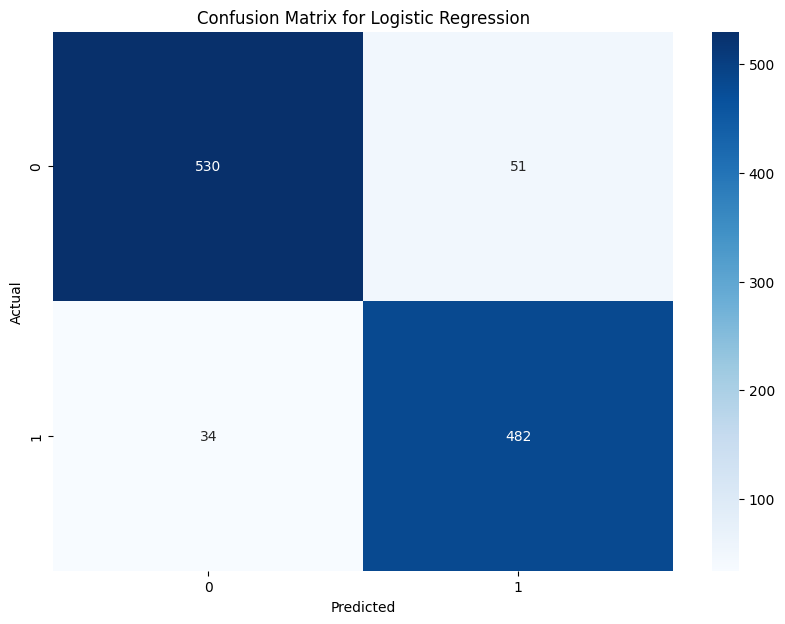

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [ ]:
selected_features

Index(['tempmax', 'tempmin', 'temp', 'feelslikemin', 'feelslike', 'dew',
       'humidity', 'precip', 'precipcover', 'preciptype', 'windgust',
       'windspeed', 'sealevelpressure', 'visibility', 'uvindex'],
      dtype='object')

In [ ]:
# LR VS SVM :  https://colab.research.google.com/drive/1az8oQPKKYSP7mrepfAoo28XreuWy-iSs?usp=sharing